In [3]:
import matplotlib.pyplot as plt
import numpy as np

In [4]:
import librosa

audio, sr = librosa.load("harvard.wav")
# audio = librosa.effects.trim(audio)[0]  # Remove silence.
# audio = librosa.util.normalize(audio)


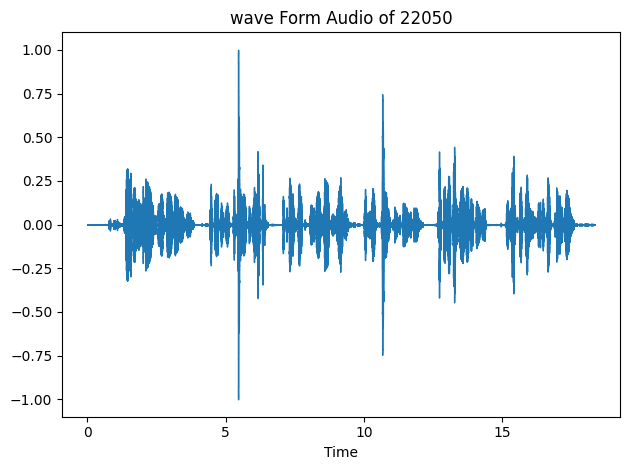

In [10]:
librosa.display.waveshow(audio, sr=sr)
plt.title("wave Form Audio of 22050")
plt.tight_layout() # avaoid from collaping
plt.show()

In [6]:
print(sr)

22050


In [7]:
#load audio with some sample rate for neural network processing
audio, sr = librosa.load("harvard.wav", sr=16000)

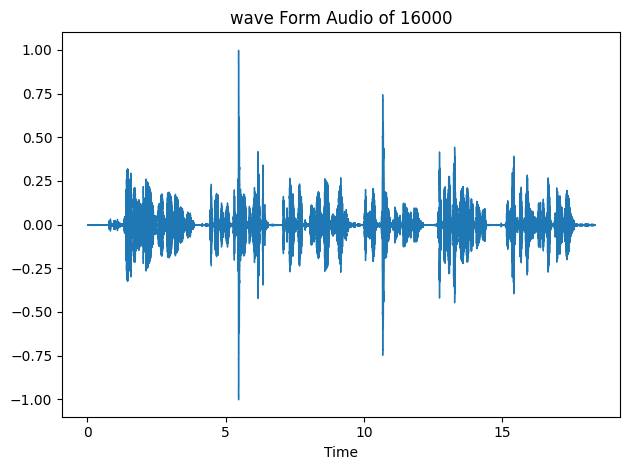

In [9]:
librosa.display.waveshow(audio,sr=sr)
plt.title("wave Form Audio of 16000")
plt.tight_layout() # avaoid from collaping
plt.show()

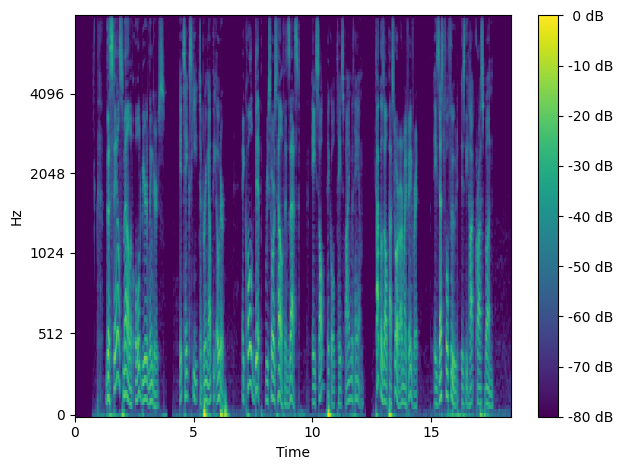

In [14]:
mel_spectrogram = librosa.feature.melspectrogram(y=audio, sr=sr)
mel_spectrogram_db = librosa.power_to_db(mel_spectrogram, ref=np.max)
librosa.display.specshow(mel_spectrogram_db, sr=sr, x_axis='time', y_axis='mel', cmap='viridis')
plt.colorbar(format='%2.0f dB')
plt.tight_layout()
plt.show()

Feature No 2

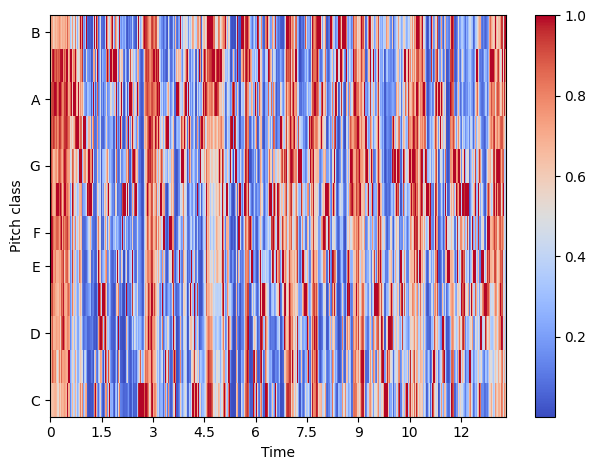

In [18]:
chromagram = librosa.feature.chroma_stft(y=audio, sr=sr)
chromagram_db = librosa.power_to_db(chromagram, ref=np.max)
frmaes = range(chromagram.shape[1])
times = librosa.frames_to_time(frmaes, sr=sr)
librosa.display.specshow(chromagram, x_axis='time', y_axis='chroma', cmap='coolwarm')
plt.colorbar()
plt.tight_layout()
plt.show()

In [23]:
y = y.squeeze()

NameError: name 'y' is not defined

3rd Feature of audio

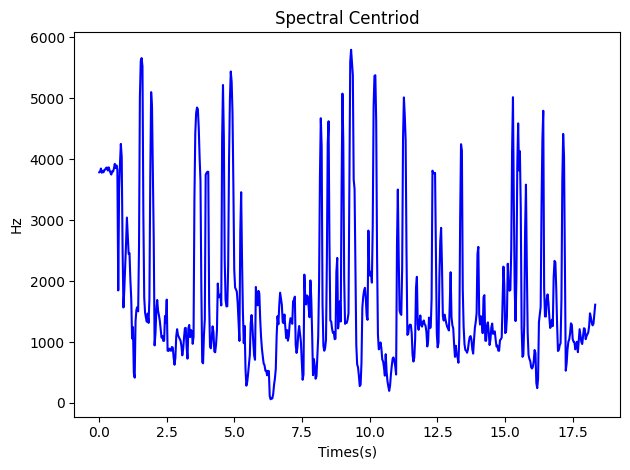

In [26]:
centroid = librosa.feature.spectral_centroid(y=audio, sr=sr)
centroid = centroid.squeeze()
plt.plot(times,centroid,color='b')
plt.xlabel('Times(s)')
plt.ylabel('Hz')
plt.title('Spectral Centriod')
plt.tight_layout()
plt.show()

Spectral contrast

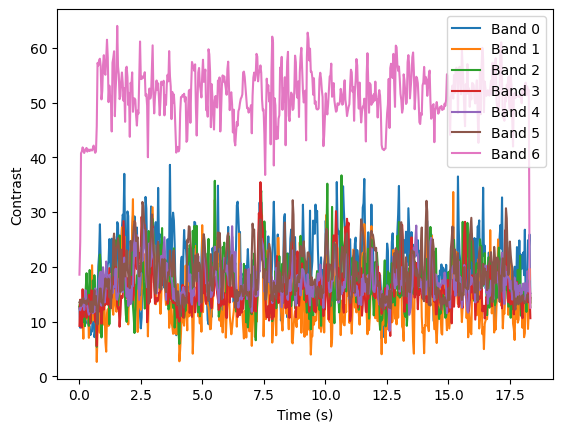

In [28]:
contrast = librosa.feature.spectral_contrast(y=audio, sr=sr)
for i in range(contrast.shape[0]):
    plt.plot(times, contrast[i], label=f'Band {i}')

plt.legend()
plt.xlabel("Time (s)")
plt.ylabel("Contrast")
plt.show()

In [25]:
centroid.shape

(1, 574)

Class Work From Above


In [ ]:
print(len(audio)/sr)

17.636371882086166


In [ ]:
import librosa
import numpy as np

def extract_features(audio_path):
    y, sr = librosa.load(audio_path)

    features = {}

    # 1. Pitch (fundamental frequency)
    pitches, magnitudes = librosa.piptrack(y=y, sr=sr)
    pitch = np.mean(pitches[pitches > 0])
    features["pitch"] = pitch

    # 2. Volume / Energy
    energy = np.mean(y**2)
    features["energy"] = energy

    # 3. Speaking Rate
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
    features["speech_rate"] = tempo

    # 4. MFCCs (best for ML training)
    mfcc = librosa.feature.mfcc(y=y, sr=sr)
    features["mfcc_mean"] = np.mean(mfcc)

    return features

In [ ]:
features = extract_features('harvard.wav')

In [ ]:
print(features)

{'pitch': np.float32(1532.1002), 'energy': np.float32(0.00314394), 'speech_rate': array([143.5546875]), 'mfcc_mean': np.float32(-10.831177)}


In [ ]:
import whisper

In [ ]:
model = whisper.load_model('medium')

100%|██████████████████████████████████████| 1.42G/1.42G [00:11<00:00, 134MiB/s]


In [ ]:
result = model.transcribe("harvard.wav")
print(result["text"])

/usr/local/lib/python3.12/dist-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")


 The stale smell of old beer lingers. It takes heat to bring out the odor. A cold dip restores health and zest. A salt pickle tastes fine with ham. Tacos al pastor are my favorite. A zestful food is the hot cross bun.


In [ ]:
import os
import csv

dataset_path = "dataset"
output_csv = "labels.csv"

label_map = {
    "Angry": 0,
    "Disgusted": 0,
    "Fearful": 0,
    "Happy": 1,
    "Neutral": 0.5,
    "Sad": 0,
    "Surprised": 0.5
}

rows = []
for class_folder in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_folder)
    if not os.path.isdir(class_path):
        continue

    label = label_map.get(class_folder)
    if label is None:
        continue

    for file in os.listdir(class_path):
        if file.endswith(".wav"):
            audio_path = os.path.join(dataset_path, class_folder, file)
            rows.append([audio_path, label])

with open(output_csv, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["audio_path", "label"])
    writer.writerows(rows)

print("CSV created successfully!")